# 01｜FF++ Deepfakes 資料準備

建立後續所有實驗共用的抽幀資料。

研究範圍固定在 FaceForensics++ c23 的兩個子集：Real 取自 `original_sequences/youtube`，Fake 取自 `manipulated_sequences/Deepfakes`。不納入 Face2Face、FaceSwap 與 NeuralTextures，讓比較對象維持單一偽造方法，避免不同偽造技術的難度差異混進結果裡。

切分沿用 FF++ 官方的 `train.json`／`val.json`／`test.json`，三組分別為 720、140、140 個影片 ID。官方切分是固定的隨機配對清單，不是依檔名編號連續分段；自行重切容易讓同一組來源影片同時落在訓練集與測試集，造成身分層級的資料洩漏。

每部影片等距抽取 16 幀，而非開頭連續 16 幀，避免取樣集中在單一場景或單一表情。

人臉偵測與裁切拆到 02 處理，讓資料分割、抽幀、裁臉三種失敗模式能分開排查。本步驟只讀取原始影片，不修改或刪除 FF++ 任何檔案。

## 1. 套件與環境

使用 `opencv-python`、`pandas`、`matplotlib`、`tqdm`。同時設定中文字型，避免圖表標籤變成方框。

In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.request import urlopen

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm


def setup_chinese_font():
    """依作業系統設定常見中文字型，避免圖表中文變成方框。"""
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = ["Noto Sans CJK TC", "Noto Sans CJK SC", "WenQuanYi Zen Hei"]

    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return candidates


font_candidates = setup_chinese_font()
print("Python：", sys.version.split()[0])
print("OpenCV：", cv2.__version__)
print("中文字型候選：", font_candidates)

Python： 3.10.19
OpenCV： 4.12.0
中文字型候選： ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei']


## 2. 參數設定

`MAX_VIDEOS_PER_CLASS` 與 `RUN_EXTRACTION` 是兩個防呆開關：前者限制處理量以先驗證流程，後者在所有資料檢查通過前不會實際寫檔。正式執行時為 `None` 與 `True`。

`WORKER_COUNT` 影響抽幀速度，但執行緒過多會讓硬碟讀寫互相競爭，未必更快。

In [2]:
# 請改成你電腦上的 FF++ 根目錄
FFPP_ROOT = Path(r"D:\資料\專題\FF++")
# 建議放在容量足夠的磁碟，不要放在 C 槽
OUTPUT_ROOT = Path("./FFPP_Deepfakes_16frames")

FRAMES_PER_VIDEO = 16
JPEG_QUALITY = 95

# 同時處理的影片數量：HDD 建議 2～4，SSD 建議 4～8
WORKER_COUNT = min(6, os.cpu_count() or 1)

# 第一次先用 4 部 Real 與 4 部 Fake 測試；正式抽取時改成 None
MAX_VIDEOS_PER_CLASS = None

# 安全開關：確認前面的資料檢查正確後，才改成 True
RUN_EXTRACTION = True

# 若本機沒有官方 split JSON，是否允許從 FF++ 官方 GitHub 讀取三份 JSON
ALLOW_OFFICIAL_SPLIT_DOWNLOAD = True

print("FF++ 根目錄：", FFPP_ROOT)
print("輸出目錄：", OUTPUT_ROOT)
print("每部影片抽取幀數：", FRAMES_PER_VIDEO)
print("並行工作執行緒：", WORKER_COUNT)
print("目前是否執行抽幀：", RUN_EXTRACTION)
print("是否允許讀取官方 split JSON：", ALLOW_OFFICIAL_SPLIT_DOWNLOAD)

FF++ 根目錄： D:\資料\專題\FF++
輸出目錄： FFPP_Deepfakes_16frames
每部影片抽取幀數： 16
並行工作執行緒： 6
目前是否執行抽幀： True
是否允許讀取官方 split JSON： True


## 3. 定位 Original 與 Deepfakes 影片

FF++ 依下載方式不同，影片可能位於 `c23/videos/` 或直接放在 `c23/` 下。程式檢查兩種結構，優先採用官方標準的 `videos` 層級。

In [3]:
def resolve_video_dir(candidates, label):
    for candidate in candidates:
        if candidate.is_dir():
            videos = sorted(candidate.glob("*.mp4"))
            if videos:
                print(f"{label}：{candidate}")
                print(f"找到 {len(videos)} 部 MP4 影片")
                return candidate, videos
    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"找不到 {label} 影片。已檢查：\n{checked}")


real_dir, real_videos = resolve_video_dir(
    [
        FFPP_ROOT / "original_sequences" / "youtube" / "c23" / "videos",
        FFPP_ROOT / "original_sequences" / "youtube" / "c23",
    ],
    "Original",
)

fake_dir, fake_videos = resolve_video_dir(
    [
        FFPP_ROOT / "manipulated_sequences" / "Deepfakes" / "c23" / "videos",
        FFPP_ROOT / "manipulated_sequences" / "Deepfakes" / "c23",
    ],
    "Deepfakes",
)

print("\n路徑與影片數量檢查完成。")

Original：D:\資料\專題\FF++\original_sequences\youtube\c23\videos
找到 1000 部 MP4 影片
Deepfakes：D:\資料\專題\FF++\manipulated_sequences\Deepfakes\c23\videos
找到 1000 部 MP4 影片

路徑與影片數量檢查完成。


## 4. 讀取 FF++ 官方資料分割

官方 split 是三份固定的隨機配對清單，不是依編號連續切成三段。這一格讀取後會驗證三件事：三組 ID 數量為 720／140／140、彼此無交集、合計為 1000。任何一項不符就中止，避免用錯誤的分割繼續往下跑。

In [4]:
OFFICIAL_SPLIT_URLS = {
    "train": "https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/train.json",
    "val": "https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/val.json",
    "test": "https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/test.json",
}


def load_official_splits(output_root, allow_download=True):
    split_dir = output_root / "metadata" / "official_splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    split_ids = {}

    for split_name, url in OFFICIAL_SPLIT_URLS.items():
        json_path = split_dir / f"{split_name}.json"
        if json_path.exists():
            pairs = json.loads(json_path.read_text(encoding="utf-8"))
        else:
            if not allow_download:
                raise FileNotFoundError(
                    f"缺少 {json_path}。請下載官方 {split_name}.json，"
                    "或將 ALLOW_OFFICIAL_SPLIT_DOWNLOAD 改成 True。"
                )
            print(f"讀取 FF++ 官方 {split_name}.json：{url}")
            with urlopen(url, timeout=30) as response:
                raw_text = response.read().decode("utf-8")
            pairs = json.loads(raw_text)
            json_path.write_text(
                json.dumps(pairs, ensure_ascii=False, indent=2),
                encoding="utf-8",
            )

        if not isinstance(pairs, list) or not all(
            isinstance(pair, list) and len(pair) == 2 for pair in pairs
        ):
            raise ValueError(f"{split_name}.json 格式不符合 FF++ 官方配對格式。")

        ids = {str(video_id).zfill(3) for pair in pairs for video_id in pair}
        split_ids[split_name] = ids

    expected_counts = {"train": 720, "val": 140, "test": 140}
    actual_counts = {name: len(ids) for name, ids in split_ids.items()}
    if actual_counts != expected_counts:
        raise ValueError(f"官方 split ID 數量異常：{actual_counts}")

    if (
        split_ids["train"] & split_ids["val"]
        or split_ids["train"] & split_ids["test"]
        or split_ids["val"] & split_ids["test"]
    ):
        raise ValueError("官方 train／val／test 之間出現重複 ID。")

    all_ids = set().union(*split_ids.values())
    if len(all_ids) != 1000:
        raise ValueError(f"官方 split 合計應有 1000 個 ID，目前為 {len(all_ids)}。")

    id_to_split = {
        video_id: split_name
        for split_name, ids in split_ids.items()
        for video_id in ids
    }
    return split_ids, id_to_split


official_split_ids, id_to_split = load_official_splits(
    OUTPUT_ROOT,
    allow_download=ALLOW_OFFICIAL_SPLIT_DOWNLOAD,
)

print({name: len(ids) for name, ids in official_split_ids.items()})
print("官方 split 驗證完成：共 1000 個 ID，三組彼此不重疊。")

讀取 FF++ 官方 train.json：https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/train.json
讀取 FF++ 官方 val.json：https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/val.json
讀取 FF++ 官方 test.json：https://raw.githubusercontent.com/ondyari/FaceForensics/master/dataset/splits/test.json
{'train': 720, 'val': 140, 'test': 140}
官方 split 驗證完成：共 1000 個 ID，三組彼此不重疊。


## 5. 建立影片層級清單

FF++ 的 Real 影片命名為 `000.mp4`，Deepfakes 命名為 `000_003.mp4`，代表來源與目標兩個身分。

Fake 影片同時記錄兩個 ID，並檢查它們是否落在同一個官方分割。若一部 Fake 影片的來源在 train、目標在 test，該影片會被標為 `cross_split` 並列入警告，因為它會讓測試集的身分在訓練時就被看過。

In [5]:
records = []

for path in real_videos:
    video_id = path.stem
    records.append(
        {
            "video_path": str(path),
            "video_name": path.name,
            "video_stem": path.stem,
            "label": 0,
            "class_name": "real",
            "source_id": video_id,
            "target_id": video_id,
            "split": id_to_split.get(video_id, "unknown"),
        }
    )

for path in fake_videos:
    parts = path.stem.split("_")
    if len(parts) < 2:
        print(f"略過無法解析的 Fake 檔名：{path.name}")
        continue
    source_id, target_id = parts[0], parts[1]
    source_split = id_to_split.get(source_id, "unknown")
    target_split = id_to_split.get(target_id, "unknown")
    records.append(
        {
            "video_path": str(path),
            "video_name": path.name,
            "video_stem": path.stem,
            "label": 1,
            "class_name": "fake",
            "source_id": source_id,
            "target_id": target_id,
            "split": source_split if source_split == target_split else "cross_split",
        }
    )

video_df = pd.DataFrame(records)
display(video_df.head())

print("\n影片分布：")
display(pd.crosstab(video_df["split"], video_df["class_name"], margins=True))

problem_rows = video_df[video_df["split"].isin(["unknown", "cross_split"])]
if len(problem_rows) > 0:
    print("警告：發現無法正常分割的影片，請先檢查下表。")
    display(problem_rows.head(20))
else:
    print("所有影片都能依官方範圍分割，未發現跨分割配對。")

,video_path,video_name,video_stem,label,class_name,source_id,target_id,split
0,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,000.mp4,000,0,real,000,000,test
1,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,001.mp4,001,0,real,001,001,train
2,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,002.mp4,002,0,real,002,002,train
3,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,003.mp4,003,0,real,003,003,test
4,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,004.mp4,004,0,real,004,004,val



影片分布：


class_name,fake,real,All
split,,,
test,140,140,280
train,720,720,1440
val,140,140,280
All,1000,1000,2000


所有影片都能依官方範圍分割，未發現跨分割配對。


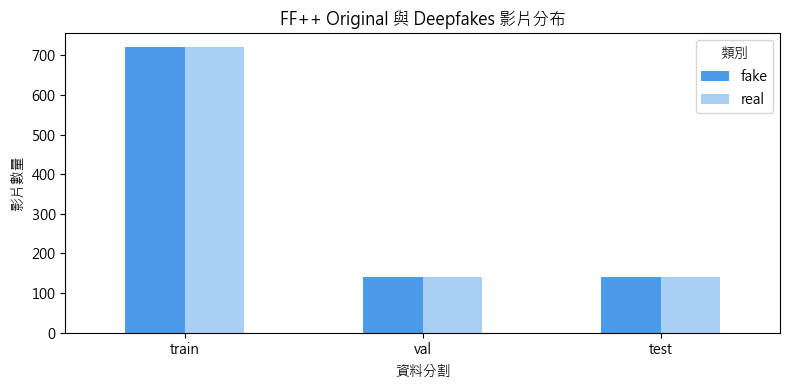

In [6]:
distribution = (
    video_df[video_df["split"].isin(["train", "val", "test"])]
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "val", "test"])
)

ax = distribution.plot(kind="bar", figsize=(8, 4), color=["#4C9BE8", "#A9CFF4"])
ax.set_title("FF++ Original 與 Deepfakes 影片分布")
ax.set_xlabel("資料分割")
ax.set_ylabel("影片數量")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="類別")
plt.tight_layout()
plt.show()

## 6. 抽樣檢查影片可讀性

只讀取少量影片，確認 OpenCV 能正常開啟並取得幀數、FPS 與解析度。若有影片無法讀取，先排除編碼器問題再繼續，不要讓錯誤累積到抽幀階段才發現。

In [7]:
def inspect_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    opened = cap.isOpened()
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if opened else 0
    fps = float(cap.get(cv2.CAP_PROP_FPS)) if opened else 0.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) if opened else 0
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) if opened else 0
    ok, frame = cap.read() if opened else (False, None)
    cap.release()
    return {
        "video_path": str(video_path),
        "opened": opened,
        "first_frame_ok": bool(ok and frame is not None),
        "frame_count": frame_count,
        "fps": round(fps, 3),
        "width": width,
        "height": height,
    }


sample_paths = real_videos[:3] + fake_videos[:3]
video_checks = pd.DataFrame(inspect_video(path) for path in sample_paths)
display(video_checks)

if not video_checks["opened"].all() or not video_checks["first_frame_ok"].all():
    raise RuntimeError("部分影片無法正常讀取，請先檢查影片或 OpenCV 編碼器。")

print("抽樣影片均可正常讀取。")

,video_path,opened,first_frame_ok,frame_count,fps,width,height
0,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,True,True,396,25.0,640,480
1,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,True,True,460,25.0,1280,720
2,D:\資料\專題\FF++\original_sequences\youtube\c23\v...,True,True,693,30.0,1280,720
3,D:\資料\專題\FF++\manipulated_sequences\Deepfakes\...,True,True,396,25.0,640,480
4,D:\資料\專題\FF++\manipulated_sequences\Deepfakes\...,True,True,460,25.0,1280,720
5,D:\資料\專題\FF++\manipulated_sequences\Deepfakes\...,True,True,693,30.0,1280,720


抽樣影片均可正常讀取。


## 7. 計算等距抽幀位置

在整部影片長度上平均取 16 個位置。影片總幀數不足 16 時，取全部可用幀。

取樣位置涵蓋整部影片，而不是集中在開頭，讓每部影片的 16 張圖片盡量涵蓋不同姿態與光線條件。

In [8]:
def evenly_spaced_indices(frame_count, samples=32):
    if frame_count <= 0:
        return []
    if frame_count <= samples:
        return list(range(frame_count))
    return [round(i * (frame_count - 1) / (samples - 1)) for i in range(samples)]


example_count = int(video_checks.iloc[0]["frame_count"])
example_indices = evenly_spaced_indices(example_count, FRAMES_PER_VIDEO)
print("範例影片總幀數：", example_count)
print("將抽取的位置：", example_indices)
print("抽取數量：", len(example_indices))

範例影片總幀數： 396
將抽取的位置： [0, 26, 53, 79, 105, 132, 158, 184, 211, 237, 263, 290, 316, 342, 369, 395]
抽取數量： 16


## 8. 選擇本次處理範圍

`MAX_VIDEOS_PER_CLASS` 設為數字時，會依 split 與類別平均抽樣，確保測試時六個組合都有資料，不會只看到單一類別。設為 `None` 才處理全部影片。

In [9]:
valid_df = video_df[video_df["split"].isin(["train", "val", "test"])].copy()

if MAX_VIDEOS_PER_CLASS is None:
    selected_df = valid_df.copy()
else:
    selected_df = (
        valid_df.sort_values("video_name")
        .groupby(["split", "class_name"], group_keys=False)
        .head(MAX_VIDEOS_PER_CLASS)
        .reset_index(drop=True)
    )

print("本次預計處理：")
display(pd.crosstab(selected_df["split"], selected_df["class_name"], margins=True))
print(f"預估最多輸出 {len(selected_df) * FRAMES_PER_VIDEO:,} 張圖片。")

本次預計處理：


class_name,fake,real,All
split,,,
test,140,140,280
train,720,720,1440
val,140,140,280
All,1000,1000,2000


預估最多輸出 32,000 張圖片。


## 9. 執行抽幀

輸出結構：

```text
OUTPUT_ROOT/
├─ train/
│  ├─ real/影片名稱/*.jpg
│  └─ fake/影片名稱/*.jpg
├─ val/
├─ test/
└─ metadata/
```

以多執行緒同時處理多部影片，支援中斷後續跑：已存在且可正常讀取的圖片會直接略過並記入清單，不會重複解碼，也不刪除既有檔案。

In [10]:
def extract_even_frames(row, output_root, frames_per_video=32, jpeg_quality=95):
    video_path = Path(row.video_path)
    output_dir = output_root / row.split / row.class_name / row.video_stem
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], f"無法開啟影片：{video_path}"

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = evenly_spaced_indices(frame_count, frames_per_video)
    image_records = []

    for sample_number, frame_index in enumerate(indices):
        image_path = output_dir / f"{sample_number:02d}_frame_{frame_index:06d}.jpg"

        if image_path.exists() and image_path.stat().st_size > 0:
            existing = cv2.imread(str(image_path))
            if existing is not None:
                image_records.append(
                    {
                        "image_path": str(image_path),
                        "source_video": str(video_path),
                        "video_stem": row.video_stem,
                        "frame_index": frame_index,
                        "split": row.split,
                        "label": int(row.label),
                        "class_name": row.class_name,
                    }
                )
                continue

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue

        saved = cv2.imwrite(
            str(image_path),
            frame,
            [cv2.IMWRITE_JPEG_QUALITY, int(jpeg_quality)],
        )
        if saved:
            image_records.append(
                {
                    "image_path": str(image_path),
                    "source_video": str(video_path),
                    "video_stem": row.video_stem,
                    "frame_index": frame_index,
                    "split": row.split,
                    "label": int(row.label),
                    "class_name": row.class_name,
                }
            )

    cap.release()
    if len(image_records) != len(indices):
        return image_records, f"{video_path.name}：預計 {len(indices)} 張，實際 {len(image_records)} 張"
    return image_records, None


if not RUN_EXTRACTION:
    print("目前 RUN_EXTRACTION=False，因此尚未執行抽幀。")
    print("確認前面檢查結果後，把 RUN_EXTRACTION 改成 True，再重新執行本格。")
    frame_df = pd.DataFrame()
    extraction_errors = []
else:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    all_frame_records = []
    extraction_errors = []
    start_time = time.time()

    if not isinstance(WORKER_COUNT, int) or WORKER_COUNT < 1:
        raise ValueError("WORKER_COUNT 必須是大於等於 1 的整數。")

    rows = list(selected_df.itertuples(index=False))
    with ThreadPoolExecutor(max_workers=WORKER_COUNT) as executor:
        futures = {
            executor.submit(
                extract_even_frames,
                row,
                OUTPUT_ROOT,
                FRAMES_PER_VIDEO,
                JPEG_QUALITY,
            ): row.video_name
            for row in rows
        }

        progress = tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"並行抽幀（{WORKER_COUNT} 執行緒）",
        )
        for future in progress:
            video_name = futures[future]
            try:
                image_records, error = future.result()
                all_frame_records.extend(image_records)
                if error is not None:
                    extraction_errors.append(error)
            except Exception as exc:
                extraction_errors.append(f"{video_name}：{type(exc).__name__}: {exc}")

    frame_df = pd.DataFrame(all_frame_records)
    elapsed = time.time() - start_time
    print(f"抽幀完成，共建立或確認 {len(frame_df):,} 張圖片，耗時 {elapsed / 60:.1f} 分鐘。")
    print(f"本次使用 {WORKER_COUNT} 個工作執行緒。")
    print(f"異常數量：{len(extraction_errors)}")
    if extraction_errors:
        display(pd.DataFrame({"error": extraction_errors}).head(20))

並行抽幀（6 執行緒）:   0%|          | 0/2000 [00:00<?, ?it/s]

抽幀完成，共建立或確認 32,000 張圖片，耗時 49.0 分鐘。
本次使用 6 個工作執行緒。
異常數量：0


## 10. 儲存 metadata

建立影片層級與圖片層級兩份 CSV。後續的裁臉與訓練 Notebook 直接讀取這些清單，而不是重新掃描資料夾推斷分割，讓分割資訊只有一個來源。

In [11]:
if not RUN_EXTRACTION:
    print("尚未執行抽幀，因此不建立圖片清單。")
else:
    metadata_dir = OUTPUT_ROOT / "metadata"
    metadata_dir.mkdir(parents=True, exist_ok=True)

    video_manifest_path = metadata_dir / "video_manifest.csv"
    frame_manifest_path = metadata_dir / "frame_manifest.csv"
    error_path = metadata_dir / "extraction_errors.json"

    selected_df.to_csv(video_manifest_path, index=False, encoding="utf-8-sig")
    frame_df.to_csv(frame_manifest_path, index=False, encoding="utf-8-sig")
    error_path.write_text(
        json.dumps(extraction_errors, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print("影片清單：", video_manifest_path)
    print("圖片清單：", frame_manifest_path)
    print("異常記錄：", error_path)

影片清單： FFPP_Deepfakes_16frames\metadata\video_manifest.csv
圖片清單： FFPP_Deepfakes_16frames\metadata\frame_manifest.csv
異常記錄： FFPP_Deepfakes_16frames\metadata\extraction_errors.json


## 11. 結果檢查

確認每個 split 的 Real／Fake 圖片數是否均衡。

原本此處另有抽幀畫面的預覽圖，因 FaceForensics++ 的授權條款限制影像再散布，已於公開版本移除。程式碼保留，可在本機重現。

class_name,fake,real
split,,
train,11520,11520
val,2240,2240
test,2240,2240


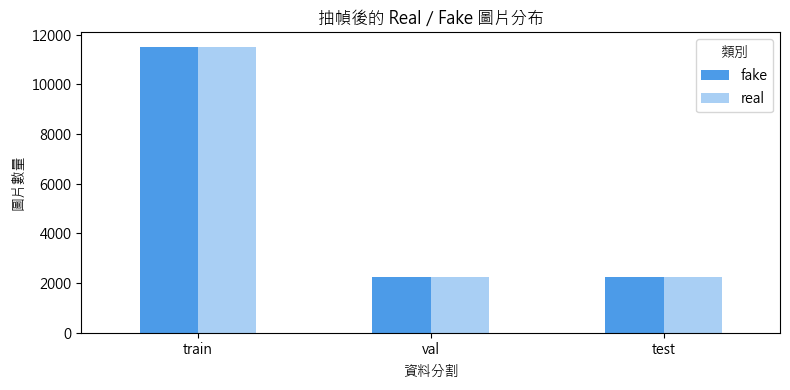

In [12]:
if frame_df.empty:
    print("目前沒有抽幀結果可供統計。")
else:
    frame_distribution = (
        frame_df.groupby(["split", "class_name"])
        .size()
        .unstack(fill_value=0)
        .reindex(["train", "val", "test"])
    )
    display(frame_distribution)

    ax = frame_distribution.plot(kind="bar", figsize=(8, 4), color=["#4C9BE8", "#A9CFF4"])
    ax.set_title("抽幀後的 Real／Fake 圖片分布")
    ax.set_xlabel("資料分割")
    ax.set_ylabel("圖片數量")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="類別")
    plt.tight_layout()
    plt.show()

In [13]:
if frame_df.empty:
    print("目前沒有圖片可顯示。")
else:
    examples = []
    for class_name in ["real", "fake"]:
        subset = frame_df[frame_df["class_name"] == class_name]
        if len(subset) > 0:
            examples.append(subset.iloc[len(subset) // 2])

    fig, axes = plt.subplots(1, len(examples), figsize=(10, 4))
    if len(examples) == 1:
        axes = [axes]

    for ax, row in zip(axes, examples):
        image_bgr = cv2.imread(row["image_path"])
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)
        title = "真實" if row["class_name"] == "real" else "Deepfake"
        ax.set_title(f"{title}\n{row['video_stem']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 12. 輸出結果

共產生 32,000 張圖片（2,000 部影片 × 16 幀），train／val／test 的 Real 與 Fake 數量完全均衡，`extraction_errors.json` 為空，無抽取失敗。

`frame_manifest.csv` 保留每張圖片對應的原始影片路徑、官方分割、類別與原始幀號。下一步（02）以 YOLOv11n-face 偵測主要人臉並裁切，Real 與對應的 Deepfake 套用相同的裁切規則。